# 1. DPD Scoring and Data Overview

**Dataset:** Genome-scale Perturb-seq — Primary Human CD4+ T Cells (Zhu, Dann et al. 2025)
**Reference:** https://virtualcellmodels.cziscience.com/dataset/genome-scale-tcell-perturb-seq

**Pseudobulk DPD scoring.** This notebook computes DPD (Dynamic Phenotype Descriptor) scores at pseudobulk resolution. Two vectors are involved:

- `v_stim`: the stimulation axis. Computed as the mean log1p fold-change between NTC (non-targeting guide) cells in the stimulated condition and NTC cells in Rest, averaged across donors. NTC cells carry no gene knockdown, so this difference isolates the effect of TCR stimulation from any perturbation effect. For Rest, there is no earlier timepoint to compare against, so `v_stim` is reused from the Stim8hr run.
- `v_pert`: the perturbation matrix, one row per gene knockdown, taken directly from `DE_stats` (already pseudobulk: one logFC + one adjusted p-value per gene per perturbation).

`DPD_stim = v_pert · v_stim`, normalized by `‖v_stim‖`. This is a purely pseudobulk computation, no single-cell perturbed data is loaded here. The only single-cell files touched are the NTC-restricted files, needed to build `v_stim`.

### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


In [2]:
# Edit these to change condition
CONDITION = 'Stim48hr'  # 'Rest', 'Stim8hr', 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
DATA_DIR = '../Data'
DESTATS_PATH = '../Data/GWCD4i.DE_stats.h5ad'

# Manually curated blocklist, built empirically from Sonic 1_prep_stv.py runs:
# genes with zero perturbed cells in the single-cell files. Applied
# BEFORE ranking/selection so excluded genes never take a core-gene slot, and
# the single-cell network ends up with the same node count as the pseudobulk one.
EXCLUDED_GENES_PATH = os.path.join(DATA_DIR, 'excluded_genes.csv')

# For Rest, v_stim is loaded from the Stim8hr run rather than computed from NTC files.
# This ensures all three conditions share the same activation axis for DPD scoring.
# VSTIM_REF_CONDITION is only used when CONDITION == 'Rest'.
VSTIM_REF_CONDITION = 'Stim8hr'

OUT_DIR = f'../Results/{CONDITION}'
os.makedirs(OUT_DIR, exist_ok=True)

# Parameters
P_THRESHOLD = 0.05
LOW_CELL_THRESHOLD = 10 # flag perturbations below this cell count in QC
TOP_N_BARS = 15 # genes shown in bar charts

print(f'Condition: {CONDITION}')
print(f'Donors: {DONORS}')
print(f'run_tag: {run_tag}')
print(f'Out dir: {OUT_DIR}')
if CONDITION == 'Rest':
    print(f'v_stim will be loaded from: ../Results/{VSTIM_REF_CONDITION}/')

Condition: Stim48hr
Donors: ['D1', 'D2', 'D3', 'D4']
run_tag: Stim48hr_D1_D2_D3_D4
Out dir: ../Results/Stim48hr


### 2. Load Data

In [3]:
import numpy as np
import pandas as pd
import anndata
import scipy.sparse
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print('Packages loaded.')

Packages loaded.


In [4]:
DE_stats = anndata.read_h5ad(DESTATS_PATH, backed='r')
print(f'DE_stats: {DE_stats.shape}  (perturbations x genes)')
print(f'Layers: {list(DE_stats.layers.keys())}')

# NTC files are only needed to compute v_stim, which requires a Stim vs Rest comparison
# among NTC (non-targeting) cells. For Rest, there is no such comparison to make
# (Rest IS the NTC baseline), so we skip loading and reuse v_stim from Stim8hr instead.
if CONDITION != 'Rest':
    stim_adatas = []
    rest_adatas = []
    for donor in DONORS:
        stim_path = os.path.join(DATA_DIR, f'{donor}_{CONDITION}.NTC.h5ad')
        rest_path = os.path.join(DATA_DIR, f'{donor}_Rest.NTC.h5ad')
        stim_adatas.append(anndata.read_h5ad(stim_path))
        rest_adatas.append(anndata.read_h5ad(rest_path))
        print(f'{donor}: stim={stim_adatas[-1].shape}, rest={rest_adatas[-1].shape}')
else:
    print('Rest condition: skipping NTC file loading (v_stim will be loaded from Stim8hr run).')

DE_stats: (33983, 10282)  (perturbations x genes)
Layers: ['adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value', 'zscore']
D1: stim=(74183, 18130), rest=(76634, 18130)
D2: stim=(88159, 18130), rest=(84058, 18130)
D3: stim=(77726, 18130), rest=(77017, 18130)
D4: stim=(83849, 18130), rest=(76821, 18130)


### 3. QC: Cells per Perturbation and NTC Sparsity

Cells per perturbation
  Mean: 603.5
  Median: 539.0
  Min: 17
  Max: 11510
  < 10 cells: 0 (0.0%)


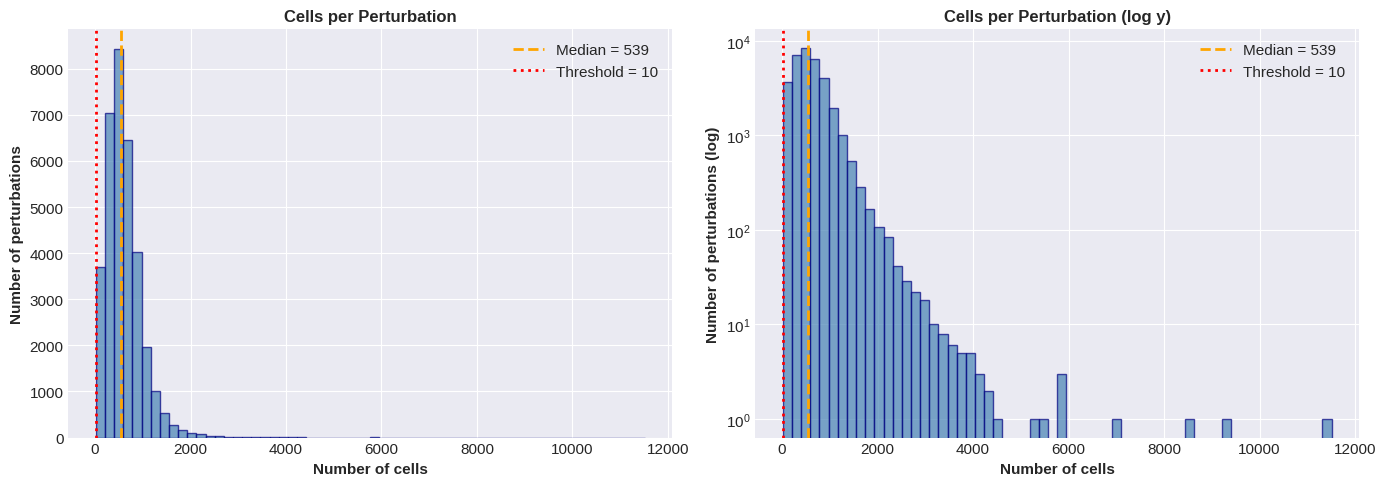

Saved: ../Results/Stim48hr/qc_cells_per_perturbation_Stim48hr_D1_D2_D3_D4.png


In [5]:
cell_counts = DE_stats.obs['n_cells_target'].dropna()
n_low = (cell_counts < LOW_CELL_THRESHOLD).sum()

print(f'Cells per perturbation')
print(f'  Mean: {cell_counts.mean():.1f}')
print(f'  Median: {cell_counts.median():.1f}')
print(f'  Min: {cell_counts.min():.0f}')
print(f'  Max: {cell_counts.max():.0f}')
print(f'  < {LOW_CELL_THRESHOLD} cells: {n_low} ({100*n_low/len(cell_counts):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, logy in zip(axes, [False, True]):
    ax.hist(cell_counts, bins=60, color='steelblue', edgecolor='navy', alpha=0.7)
    ax.axvline(cell_counts.median(), color='orange', lw=2, linestyle='--',
               label=f'Median = {cell_counts.median():.0f}')
    ax.axvline(LOW_CELL_THRESHOLD, color='red', lw=2, linestyle=':',
               label=f'Threshold = {LOW_CELL_THRESHOLD}')
    ax.set_xlabel('Number of cells', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of perturbations' + (' (log)' if logy else ''), fontsize=11, fontweight='bold')
    ax.set_title('Cells per Perturbation' + (' (log y)' if logy else ''), fontsize=12, fontweight='bold')
    ax.legend()
    if logy:
        ax.set_yscale('log')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'qc_cells_per_perturbation_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

In [6]:
# NTC sparsity check, only run when NTC files were loaded
if CONDITION != 'Rest':
    def _sparsity_stats(adatas, label):
        n_cells_total = 0
        n_genes = adatas[0].shape[1]
        nonzero_counts = np.zeros(n_genes, dtype=np.int64)
        allzero_mask = np.ones(n_genes, dtype=bool)
        for a in adatas:
            X = a.X
            if scipy.sparse.issparse(X):
                nz = np.asarray((X != 0).sum(axis=0)).ravel()
                az = np.asarray((X != 0).sum(axis=0)).ravel() == 0
            else:
                X = np.asarray(X)
                nz = (X != 0).sum(axis=0)
                az = nz == 0
            nonzero_counts += nz
            allzero_mask &= az
            n_cells_total += a.shape[0]
        n_allzero = allzero_mask.sum()
        mean_nonzero_frac = (nonzero_counts / n_cells_total).mean()
        print(f'{label} ({n_cells_total:,} cells, {n_genes:,} genes)')
        print(f'  All-zero genes: {n_allzero} ({100*n_allzero/n_genes:.1f}%)')
        print(f'  Mean non-zero/gene: {mean_nonzero_frac:.3f}')
        print()

    _sparsity_stats(stim_adatas, f'NTC-Stim ({CONDITION})')
    _sparsity_stats(rest_adatas, 'NTC-Rest')
else:
    print('Rest condition: NTC sparsity check skipped.')

NTC-Stim (Stim48hr) (323,917 cells, 18,130 genes)
  All-zero genes: 125 (0.7%)
  Mean non-zero/gene: 0.238

NTC-Rest (314,530 cells, 18,130 genes)
  All-zero genes: 100 (0.6%)
  Mean non-zero/gene: 0.206



### 4. Compute or Load v_stim

`v_stim` = mean log1p fold-change (NTC-stimulated minus NTC-Rest) across donors, restricted to genes with a consistent directional change (raw p < 0.05, one-sample t-test across donors). Non-significant genes are zeroed out.

For Rest: `v_stim` cannot be computed this way (Rest is the baseline, there is nothing earlier to subtract), so it is loaded from the Stim8hr run's saved output instead.

In [7]:
def mean_log1p(adata):
    X = adata.X
    if scipy.sparse.issparse(X):
        X = X.toarray()
    X = X.astype(np.float32)
    totals = X.sum(axis=1, keepdims=True)
    totals = np.where(totals == 0, 1.0, totals)
    return np.log1p(X / totals * 1e4).mean(axis=0)

In [8]:
if CONDITION != 'Rest':
    # Standard path: compute v_stim from NTC files for this condition
    donor_stim_means = np.stack([mean_log1p(a) for a in stim_adatas])  # (n_donors, n_genes)
    donor_rest_means = np.stack([mean_log1p(a) for a in rest_adatas])
    donor_logfc = donor_stim_means - donor_rest_means
    mean_logfc = donor_logfc.mean(axis=0)
    print(f'Computed logFC for {len(DONORS)} donors, {mean_logfc.shape[0]:,} genes')
    print(f'Mean logFC range: [{mean_logfc.min():.3f}, {mean_logfc.max():.3f}]')

    if len(DONORS) >= 3:
        _, p_vals = stats.ttest_1samp(donor_logfc, popmean=0, axis=0)
        p_stim = p_vals.astype(np.float32)
        print(f'Significance: one-sample t-test, raw p (n={len(DONORS)}, df={len(DONORS)-1})')
    elif len(DONORS) == 2:
        _, p_vals = stats.ttest_rel(donor_stim_means, donor_rest_means, axis=0)
        p_stim = p_vals.astype(np.float32)
        print('Significance: paired t-test, raw p (n=2, df=1)')
    else:
        p_stim = np.where(mean_logfc != 0, 0.0, 1.0).astype(np.float32)
        print('Single donor, retaining all non-zero logFC genes')

    sig_mask = p_stim <= P_THRESHOLD
    v_stim = np.where(sig_mask, mean_logfc, 0.0).astype(np.float32)
    gene_ids_ntc = stim_adatas[0].var_names.values

    print(f'\nv_stim: {sig_mask.sum():,} significant genes ({100*sig_mask.mean():.1f}%)')
    print(f'v_stim range: [{v_stim.min():.3f}, {v_stim.max():.3f}]')
    print(f'v_stim L2 norm: {np.linalg.norm(v_stim):.4f}')
else:
    vstim_ref_dir = f'../Results/{VSTIM_REF_CONDITION}'
    vstim_ref_path = os.path.join(vstim_ref_dir, f'v_stim_{VSTIM_REF_CONDITION}_{donors_tag}.csv')
    print(f'Rest condition: loading v_stim from {vstim_ref_path}')
    v_stim_df = pd.read_csv(vstim_ref_path)
    v_stim = v_stim_df['logFC_sig'].values.astype(np.float32)
    p_stim = v_stim_df['p_value'].values.astype(np.float32)
    sig_mask = v_stim_df['significant'].values.astype(bool)
    gene_ids_ntc = v_stim_df['ensembl_id'].values
    print(f'v_stim: {sig_mask.sum():,} significant genes ({100*sig_mask.mean():.1f}%)')
    print(f'v_stim range: [{v_stim.min():.3f}, {v_stim.max():.3f}]')
    print(f'v_stim L2 norm: {np.linalg.norm(v_stim):.4f}')

Computed logFC for 4 donors, 18,130 genes
Mean logFC range: [-2.422, 3.047]
Significance: one-sample t-test, raw p (n=4, df=3)

v_stim: 3,284 significant genes (18.1%)
v_stim range: [-0.956, 3.047]
v_stim L2 norm: 20.4570


### Apply Gene Exclusion List

Genes with zero usable single-cell data on Sonic (found via `1_prep_stv.py` runs) are removed here, before any ranking happens, so a gene that would otherwise rank highly never occupies a core-gene slot that Sonic can't actually build a network node for.

In [9]:
if os.path.exists(EXCLUDED_GENES_PATH):
    excluded_df = pd.read_csv(EXCLUDED_GENES_PATH)
    excluded_gene_set = set(
        excluded_df.loc[excluded_df['condition'] == CONDITION, 'gene'])
    print(f'Loaded exclusion list: {EXCLUDED_GENES_PATH}')
    print(f'Genes excluded for {CONDITION}: {sorted(excluded_gene_set) if excluded_gene_set else "none"}')
else:
    excluded_gene_set = set()
    print(f'{EXCLUDED_GENES_PATH} not found, proceeding with no exclusions.')

Loaded exclusion list: ../Data/excluded_genes.csv
Genes excluded for Stim48hr: ['CEP43', 'H2AZ1', 'HAPSTR1', 'MICOS10', 'POGLUT3', 'SKIC8']


QC: distribution of significant DE genes per perturbation, useful before scoring.

Perturbations after exclusion: 11,275 (6 genes removed)
Perturbations in Stim48hr: 11,275
Sig genes per perturbation; mean: 39.2, median: 2.0
Range: [0, 4668]


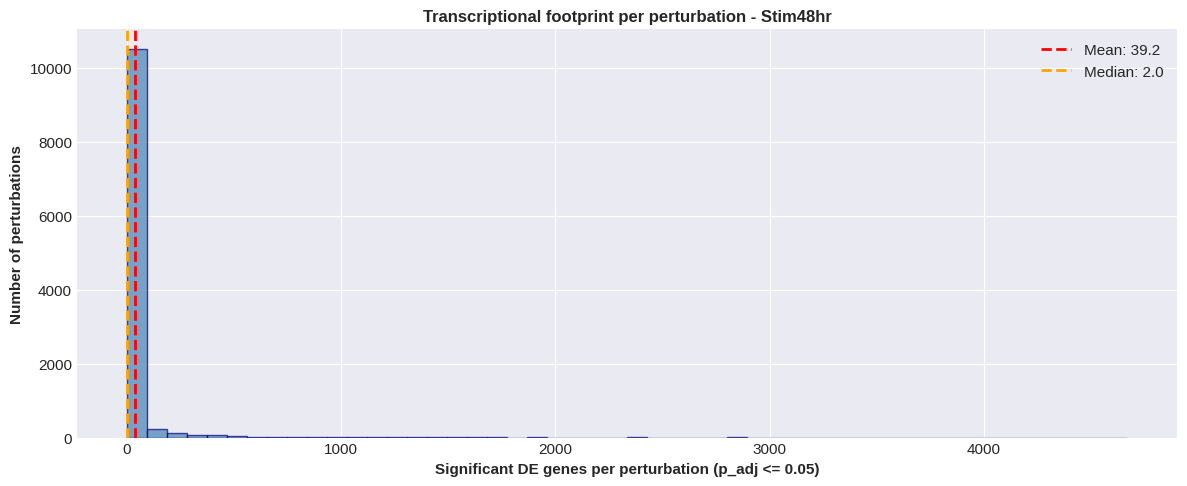

Saved: ../Results/Stim48hr/qc_sig_genes_per_pert_Stim48hr_D1_D2_D3_D4.png


In [10]:
DE_stim = DE_stats[
    (DE_stats.obs['culture_condition'] == CONDITION) &
    (~DE_stats.obs['target_contrast_gene_name'].isin(excluded_gene_set))]
print(f'Perturbations after exclusion: {DE_stim.n_obs:,} '
      f'({len(excluded_gene_set)} genes removed)')

def get_dense(adata, layer):
    mat = adata.layers[layer]
    if scipy.sparse.issparse(mat):
        mat = mat.toarray()
    return mat.astype(np.float32)

p_adj_pert = get_dense(DE_stim, 'adj_p_value')
sig_gene_counts = ((p_adj_pert <= P_THRESHOLD) & (~np.isnan(p_adj_pert))).sum(axis=1)

print(f'Perturbations in {CONDITION}: {len(sig_gene_counts):,}')
print(f'Sig genes per perturbation; mean: {sig_gene_counts.mean():.1f}, median: {np.median(sig_gene_counts):.1f}')
print(f'Range: [{sig_gene_counts.min()}, {sig_gene_counts.max()}]')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sig_gene_counts, bins=50, color='steelblue', edgecolor='navy', alpha=0.7)
ax.axvline(sig_gene_counts.mean(), color='red', lw=2, linestyle='--', label=f'Mean: {sig_gene_counts.mean():.1f}')
ax.axvline(np.median(sig_gene_counts), color='orange', lw=2, linestyle='--', label=f'Median: {np.median(sig_gene_counts):.1f}')
ax.set_xlabel(f'Significant DE genes per perturbation (p_adj <= {P_THRESHOLD})', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of perturbations', fontsize=11, fontweight='bold')
ax.set_title(f'Transcriptional footprint per perturbation - {CONDITION}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
p = os.path.join(OUT_DIR, f'qc_sig_genes_per_pert_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

### 5. Align Vectors and Build v_pert

`v_stim` is in NTC gene space (from the NTC h5ad files). `DE_stats` is in a slightly different gene space (a subset). We find the intersection and align `v_stim` to the common gene set, then build `v_pert`: for each perturbation, the logFC from `DE_stats`, masked to zero wherever `adj_p_value > P_THRESHOLD`.

In [11]:
gene_ids_de_stats = DE_stats.var_names.values

common_genes, ntc_idx, de_idx = np.intersect1d(gene_ids_ntc, gene_ids_de_stats, return_indices=True)

print(f'Genes in v_stim space: {len(gene_ids_ntc):,}')
print(f'Genes in DE_stats: {len(gene_ids_de_stats):,}')
print(f'Common (used): {len(common_genes):,}')

# Align v_stim to common gene space
v_stim_aligned = v_stim[ntc_idx]
stim_norm = float(np.linalg.norm(v_stim_aligned))
print(f'v_stim aligned norm: {stim_norm:.4f}')

Genes in v_stim space: 18,130
Genes in DE_stats: 10,282
Common (used): 10,282
v_stim aligned norm: 20.1356


In [12]:
# Build v_pert: one row per perturbation, columns = common genes
# Entries are log_fc values where adj_p_value <= P_THRESHOLD, zero otherwise
logfc_mat = get_dense(DE_stim, 'log_fc')
v_pert = np.where(p_adj_pert <= P_THRESHOLD, logfc_mat, 0.0).astype(np.float32)
v_pert = np.nan_to_num(v_pert, nan=0.0)
v_pert = v_pert[:, de_idx]

print(f'v_pert: {v_pert.shape}  (perturbations x common genes)')
del logfc_mat
import gc; gc.collect()

v_pert: (11275, 10282)  (perturbations x common genes)


2069

### 6. Compute and Normalise DPD Scores

`DPD_stim = v_pert . v_stim`, computed explicitly with `np.dot` per perturbation, then normalised by `‖v_stim‖` (this makes DPD comparable to a projection onto a unit-length reference direction, equivalent to what `cstarpy`'s `CellStateTransition` does internally by pre-normalising its STV to unit length. cstarpy has no standalone DPD-normalisation function outside that class, so this is the direct numpy equivalent).

In [13]:
dpd_stim_scores = np.array([np.dot(v_pert[i], v_stim_aligned) for i in range(v_pert.shape[0])], dtype=np.float32)

dpd_df = DE_stim.obs[[
    'target_contrast_gene_name', 'target_contrast',
    'culture_condition', 'n_cells_target',
    'n_total_de_genes', 'ontarget_effect_size',
    'ontarget_significant', 'offtarget_flag'
]].copy()

dpd_df['n_sig_genes'] = sig_gene_counts
dpd_df['DPD_stim'] = dpd_stim_scores
dpd_df['DPD_stim_norm'] = (dpd_df['DPD_stim'] / stim_norm).astype(np.float32)
# Signed ranking (not abs()): highest positive first, most negative last
dpd_df = dpd_df.sort_values('DPD_stim_norm', ascending=False).reset_index(drop=True)

print(f'DPD_stim_norm range: [{dpd_df["DPD_stim_norm"].min():.3f}, {dpd_df["DPD_stim_norm"].max():.3f}]')
print(f'Positive DPD_stim (activation-enhancing): {(dpd_df["DPD_stim_norm"] > 0).sum():,}')
print(f'Negative DPD_stim (activation-suppressing): {(dpd_df["DPD_stim_norm"] < 0).sum():,}')

DPD_stim_norm range: [-23.398, 2.485]
Positive DPD_stim (activation-enhancing): 1,789
Negative DPD_stim (activation-suppressing): 3,564


### 7. Figures

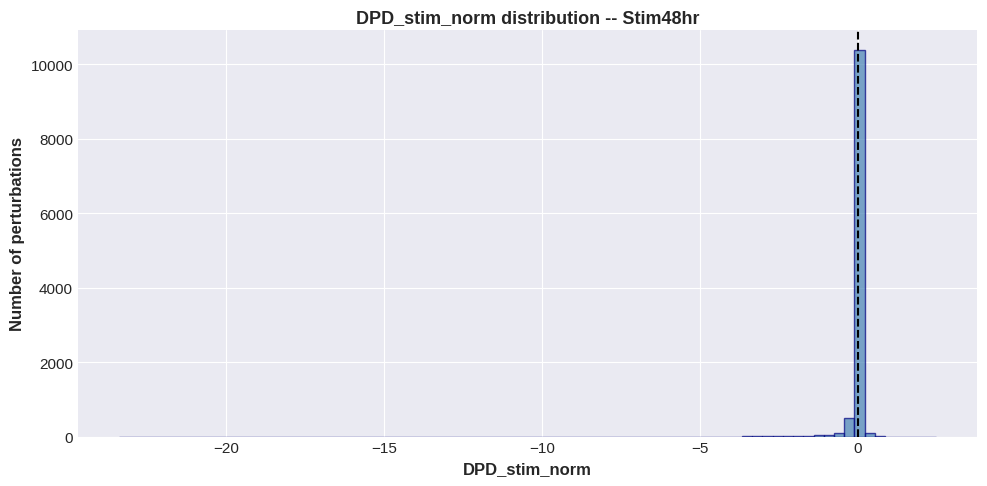

Saved: ../Results/Stim48hr/dpd_stim_histogram_Stim48hr_D1_D2_D3_D4.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dpd_df['DPD_stim_norm'], bins=80, color='steelblue', edgecolor='navy', alpha=0.7)
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('DPD_stim_norm', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of perturbations', fontsize=12, fontweight='bold')
ax.set_title(f'DPD_stim_norm distribution -- {CONDITION}', fontsize=13, fontweight='bold')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'dpd_stim_histogram_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

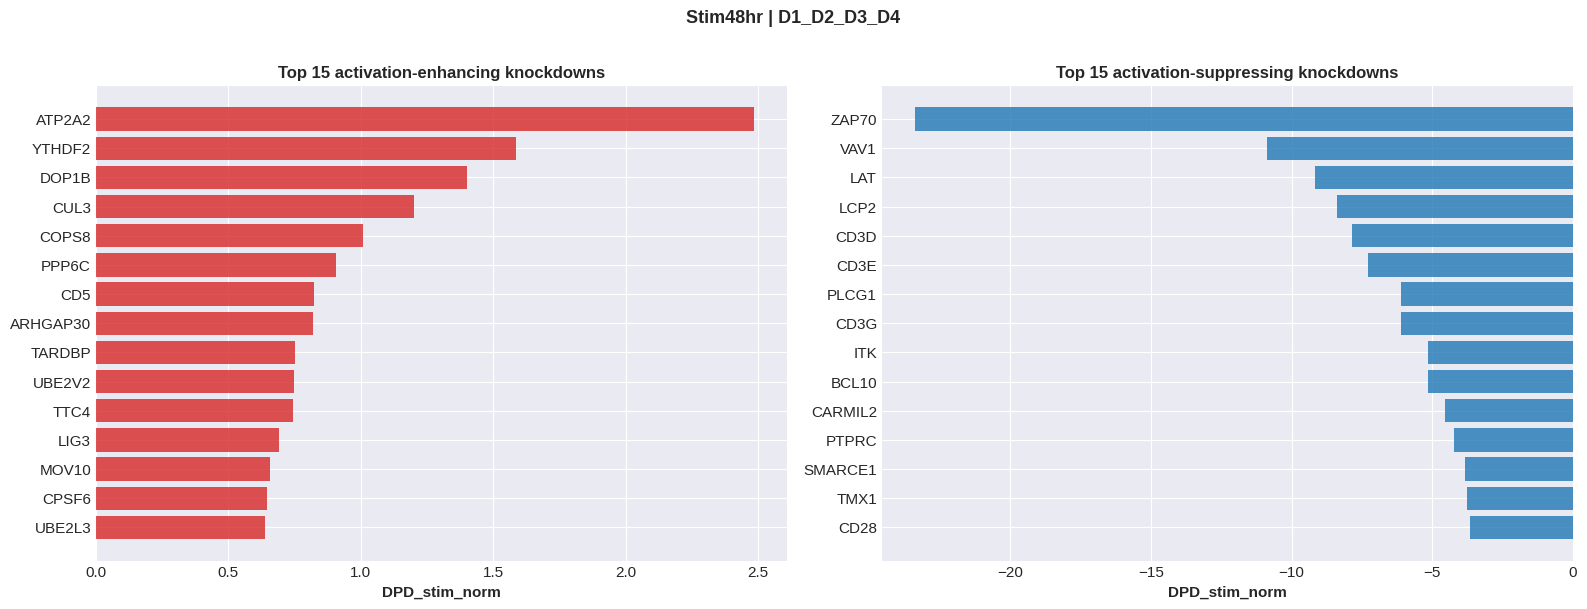

Saved: ../Results/Stim48hr/dpd_top_genes_barchart_Stim48hr_D1_D2_D3_D4.png


In [15]:
top_act = dpd_df.nlargest(TOP_N_BARS, 'DPD_stim_norm')
top_sup = dpd_df.nsmallest(TOP_N_BARS, 'DPD_stim_norm')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(top_act['target_contrast_gene_name'], top_act['DPD_stim_norm'], color='#d62728', alpha=0.8)
ax.set_xlabel('DPD_stim_norm', fontsize=11, fontweight='bold')
ax.set_title(f'Top {TOP_N_BARS} activation-enhancing knockdowns', fontsize=12, fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
ax.barh(top_sup['target_contrast_gene_name'], top_sup['DPD_stim_norm'], color='#1f77b4', alpha=0.8)
ax.set_xlabel('DPD_stim_norm', fontsize=11, fontweight='bold')
ax.set_title(f'Top {TOP_N_BARS} activation-suppressing knockdowns', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.suptitle(f'{CONDITION} | {donors_tag}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(OUT_DIR, f'dpd_top_genes_barchart_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

### 8. Save

In [16]:
# Main DPD scores table: all perturbations, ranked by |DPD_stim_norm|
dpd_path = os.path.join(OUT_DIR, f'DPD_scores_{run_tag}.csv')
dpd_df.to_csv(dpd_path, index=False)
print(f'Saved: {dpd_path}')

# Quality-filtered ranked list for sharing (ontarget_significant, no offtarget, n_sig_genes >= 1)
# Sorted by SIGNED DPD_stim_norm (not abs()) -- Notebook 2 takes top-N / bottom-N
# slices directly from this ordering.
dpd_filtered = dpd_df[
    (dpd_df['ontarget_significant'] == True) &
    (dpd_df['offtarget_flag'] == False) &
    (dpd_df['n_sig_genes'] >= 1)].copy()
dpd_filtered = dpd_filtered.drop_duplicates(subset='target_contrast_gene_name', keep='first')
dpd_filtered = dpd_filtered.sort_values('DPD_stim_norm', ascending=False).reset_index(drop=True)
dpd_filtered.index += 1
ranked_path = os.path.join(OUT_DIR, f'DPD_ranked_filtered_{run_tag}.csv')
dpd_filtered.to_csv(ranked_path, index_label='rank')
print(f'Saved: {ranked_path}  ({len(dpd_filtered):,} genes after quality filter)')

# v_stim, aligned to common gene space (for Rest, this re-saves the Stim8hr-derived
# vector re-aligned to Rest's own common gene space, so downstream notebooks can
# load it with the same interface regardless of condition)
stim_vec_df = pd.DataFrame({
    'ensembl_id': common_genes,
    'logFC_sig': v_stim_aligned,
    'p_value': p_stim[ntc_idx],
    'significant': sig_mask[ntc_idx]})
stim_vec_path = os.path.join(OUT_DIR, f'v_stim_{run_tag}.csv')
stim_vec_df.to_csv(stim_vec_path, index=False)
print(f'Saved: {stim_vec_path}')

Saved: ../Results/Stim48hr/DPD_scores_Stim48hr_D1_D2_D3_D4.csv
Saved: ../Results/Stim48hr/DPD_ranked_filtered_Stim48hr_D1_D2_D3_D4.csv  (6,367 genes after quality filter)
Saved: ../Results/Stim48hr/v_stim_Stim48hr_D1_D2_D3_D4.csv
